In [1]:
!pip install river ucimlrepo


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 51.7 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.3 which is incompatible.
dask-cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.3 which is incompatible.


In [5]:
from river.tree import HoeffdingTreeClassifier
from river import evaluate, metrics, stream, preprocessing
from ucimlrepo import fetch_ucirepo
import pandas as pd


In [6]:
# fetch dataset
abalone = fetch_ucirepo(id=1)

# data (as pandas dataframes)
X = abalone.data.features
y = abalone.data.targets["Rings"]


In [7]:
# Criação da variável categórica baseada em quartis
q1 = y.quantile(0.25)
q3 = y.quantile(0.75)

# Dividindo em 3 categorias: 1º quartil, intermediários (2º-3º), e 4º quartil
y_class = pd.cut(
    y,
    bins=[y.min() - 1, q1, q3, y.max()],
    labels=["Baixo", "Médio", "Alto"]
)


In [9]:
# Ajuste da variável categórica 'Sex'
X = X.copy()
X.loc[:, "Sex"] = X["Sex"].map({'M': 0, 'F': 1, 'I': 2}).astype(float)



In [10]:
# Modelo e métrica
tree = preprocessing.OneHotEncoder() | HoeffdingTreeClassifier()
acc = metrics.Accuracy()


In [11]:
# Avaliação progressive (Test-then-Train)
evaluate.progressive_val_score(
    dataset=stream.iter_pandas(X, y_class),
    model=tree,
    metric=acc,
    print_every=100,
    show_time=True,
    show_memory=True
)


[100] Accuracy: 30.30% – 00:00:00 – 4.91 MiB
[200] Accuracy: 34.17% – 00:00:00 – 8.81 MiB
[300] Accuracy: 35.12% – 00:00:01 – 11.93 MiB
[400] Accuracy: 39.35% – 00:00:02 – 14.92 MiB
[500] Accuracy: 43.29% – 00:00:03 – 17.12 MiB
[600] Accuracy: 44.07% – 00:00:04 – 19.47 MiB
[700] Accuracy: 43.92% – 00:00:06 – 21.86 MiB
[800] Accuracy: 45.06% – 00:00:08 – 23.84 MiB
[900] Accuracy: 41.49% – 00:00:10 – 26.17 MiB
[1,000] Accuracy: 37.34% – 00:00:12 – 27.49 MiB
[1,100] Accuracy: 34.30% – 00:00:14 – 29.92 MiB
[1,200] Accuracy: 34.28% – 00:00:17 – 32.45 MiB
[1,300] Accuracy: 34.87% – 00:00:20 – 34.19 MiB
[1,400] Accuracy: 37.10% – 00:00:23 – 35.75 MiB
[1,500] Accuracy: 37.56% – 00:00:27 – 37.76 MiB
[1,600] Accuracy: 37.59% – 00:00:31 – 39.41 MiB
[1,700] Accuracy: 39.32% – 00:00:37 – 41.03 MiB
[1,800] Accuracy: 40.47% – 00:00:43 – 42.96 MiB
[1,900] Accuracy: 41.39% – 00:00:49 – 44.37 MiB
[2,000] Accuracy: 42.62% – 00:00:56 – 45.91 MiB
[2,100] Accuracy: 42.69% – 00:01:04 – 47.11 MiB
[2,200] Accu

Accuracy: 44.59%

In [12]:
import matplotlib.pyplot as plt

In [13]:
#  Loop com coleta de métricas
accuracies = []
steps = []

for i, (x, yi) in enumerate(stream.iter_pandas(X, y_class), start=1):
    y_pred = tree.predict_one(x)
    acc.update(yi, y_pred)
    tree.learn_one(x, yi)

    # Armazena a cada 100 instâncias
    if i % 100 == 0:
        accuracies.append(acc.get())
        steps.append(i)


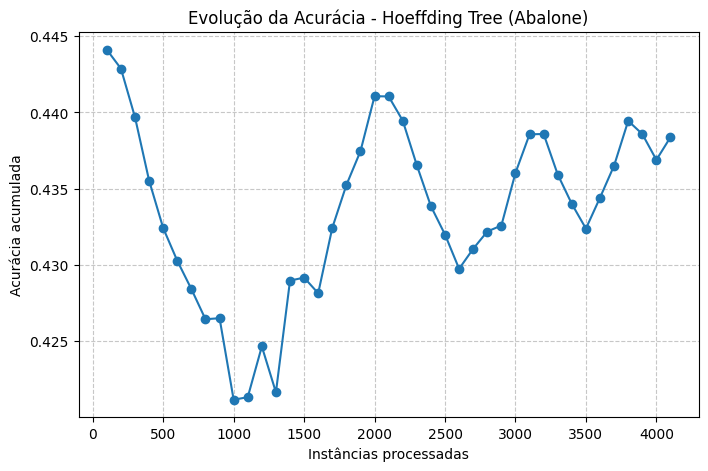

Acurácia final: 44.00%


In [14]:
#  Gráfico da evolução da acurácia
plt.figure(figsize=(8, 5))
plt.plot(steps, accuracies, marker='o', linestyle='-', linewidth=1.5)
plt.title("Evolução da Acurácia - Hoeffding Tree (Abalone)")
plt.xlabel("Instâncias processadas")
plt.ylabel("Acurácia acumulada")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f"Acurácia final: {acc.get():.2%}")